# Star Trek Franchise EDA
Explore the extracted Star Trek database: shows, episodes, movies, books, characters, species, and starships.
Also includes a wikitext prototype section for developing new fields against the raw dump.

In [1]:
%pip install dask
%pip install "dask[array]"
%pip install np
%pip install pandas
%pip install pyarrow
%pip install mwparserfromhell
%pip install seaborn
%pip install sqlalchemy
%pip install lxml

/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/

In [2]:
from __future__ import annotations

%pip install dask

import re
import sys
from pathlib import Path

import dask.dataframe as dd
import mwparserfromhell
import pandas as pd
import seaborn as sns
from IPython.display import display
from matplotlib import pyplot as plt
from sqlalchemy import create_engine

# Make the src package importable from notebooks/
REPO = Path("../").resolve()
if str(REPO / "src") not in sys.path:
    sys.path.insert(0, str(REPO / "src"))

from wiki_dumps.parse.stream import iter_pages_from_xml_bytes

DB_PATH  = REPO / "data/databases/star_trek.db"
DUMP_DIR = REPO / "data/dumps"

engine = create_engine(f"sqlite:///{DB_PATH}")
print("DB:", DB_PATH)
print("Dump dir:", DUMP_DIR)

/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip


Note: you may need to restart the kernel to use updated packages.
DB: /home/benwright/Documents/GitHub/wiki/data/databases/star_trek.db
Dump dir: /home/benwright/Documents/GitHub/wiki/data/dumps


## 1  Load tables

In [3]:
shows      = pd.read_sql_table("trek_shows",      engine)
episodes   = pd.read_sql_table("trek_episodes",   engine)
movies     = pd.read_sql_table("trek_movies",     engine)
books      = pd.read_sql_table("trek_books",      engine)
characters = pd.read_sql_table("trek_characters", engine)
species    = pd.read_sql_table("trek_species",    engine)
starships  = pd.read_sql_table("trek_starships",  engine)

engine.dispose()

print(
    f"shows={len(shows):,}  episodes={len(episodes):,}  movies={len(movies):,}  "
    f"books={len(books):,}  characters={len(characters):,}  "
    f"species={len(species):,}  starships={len(starships):,}"
)


shows=20  episodes=874  movies=0  books=0  characters=424  species=120  starships=0


## 2  Shows

In [4]:
display(shows[["title", "abbreviation", "series_type", "network",
               "premiere_year", "finale_year", "total_seasons", "total_episodes"]]
        .sort_values("premiere_year"))

,title,abbreviation,series_type,network,premiere_year,finale_year,total_seasons,total_episodes
2,Star Trek: The Original Series,NaN,live_action,NBC,1966.0,1969.0,3.0,79.0
5,Star Trek: The Animated Series,TAS,animated,"NBC""Animated Star Trek: Series Background""",1973.0,1974.0,2.0,22.0
1,Star Trek: The Next Generation,TNG,live_action,"First-run syndicationTrek Core Staff. ""Selling...",1987.0,1994.0,7.0,178.0
3,Star Trek: Deep Space Nine,DS9,live_action,First-run syndication,1993.0,1999.0,7.0,176.0
0,Star Trek: Voyager,VOY,live_action,"UPNNguyen, Will (2 May 2015). ""Twenty Years La...",1995.0,2001.0,7.0,172.0
4,Star Trek: Enterprise,ENT,live_action,UPN,2001.0,2005.0,4.0,98.0
9,Star Trek: Discovery,DIS,live_action,CBS,2017.0,NaN,5.0,65.0
10,After Trek,NaN,live_action,CBS All Access,2017.0,2018.0,1.0,14.0
16,The Ready Room,NaN,live_action,CBS All Access,2019.0,2021.0,NaN,107.0
11,Star Trek: Picard,PIC,live_action,CBS All Access,2020.0,2020.0,3.0,30.0


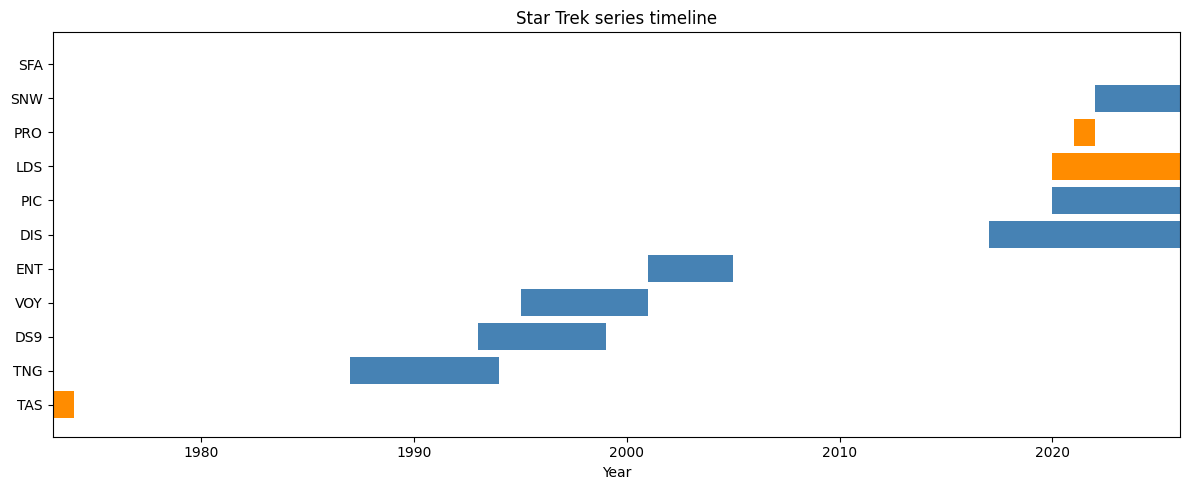

In [5]:
# Timeline: each show as a horizontal bar (premiere → finale)
CURRENT_YEAR = 2026
df = shows.dropna(subset=["premiere_year"]).copy()
# For ongoing shows (NaN finale) and cases where finale == premiere (bad parse),
# treat the show as still running.
df["finale_year"] = df.apply(
    lambda r: CURRENT_YEAR if (pd.isna(r["finale_year"]) or r["finale_year"] <= r["premiere_year"])
    else r["finale_year"],
    axis=1,
)
df = df.sort_values("premiere_year")

fig, ax = plt.subplots(figsize=(12, 5))
for i, row in enumerate(df.itertuples()):
    label = row.abbreviation or row.title
    color = "steelblue" if row.series_type == "live_action" else "darkorange"
    ax.barh(label, row.finale_year - row.premiere_year, left=row.premiere_year, color=color)
ax.set_xlabel("Year")
ax.set_title("Star Trek series timeline")
plt.tight_layout()

## 3  Episodes

In [6]:
episodes.info()
display(episodes.head(3))

<class 'pandas.DataFrame'>
RangeIndex: 874 entries, 0 to 873
Data columns (total 12 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   id               874 non-null    int64  
 1   page_id          874 non-null    int64  
 2   title            874 non-null    str    
 3   show_title       864 non-null    str    
 4   season           727 non-null    float64
 5   episode_number   852 non-null    float64
 6   production_code  686 non-null    str    
 7   air_date         7 non-null      str    
 8   stardate         0 non-null      str    
 9   director         734 non-null    str    
 10  writer           744 non-null    str    
 11  description      753 non-null    str    
dtypes: float64(2), int64(2), str(8)
memory usage: 276.3 KB


,id,page_id,title,show_title,season,episode_number,production_code,air_date,stardate,director,writer,description
0,1,27075,List of Star Trek: Enterprise episodes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,right|300px\nStar Trek: Enterprise is an Ameri...
1,2,27090,List of Star Trek: The Original Series episodes,NaN,NaN,NaN,NaN,12,NaN,12,31,"right|228x228px\nCreated by Gene Roddenberry, ..."
2,3,27092,Beyond the Farthest Star,Star Trek: The Animated Series,1.0,1.0,NaN,NaN,NaN,Hal Sutherland,Samuel A. Peeples,While exploring on the outermost rim of the ga...


<Axes: title={'center': 'Episodes per show (top 20)'}, ylabel='show_title'>

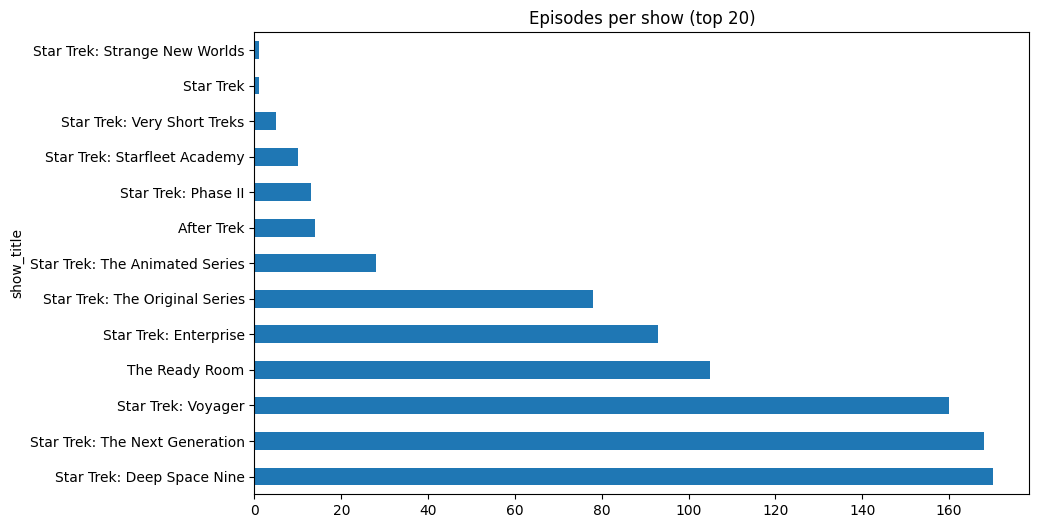

In [7]:
# Episode count per show.
# Deduplicate by (show_title, title) because show pages also emit Episode list
# rows as a fallback, which may overlap with individual episode pages.
episodes_dedup = episodes.dropna(subset=["show_title", "title"]).drop_duplicates(
    subset=["show_title", "title"]
)
episodes_dedup["show_title"].value_counts().head(20).plot.barh(
    figsize=(10, 6), title="Episodes per show (top 20)"
)

<Axes: title={'center': 'Most prolific directors (top 20)'}, ylabel='director'>

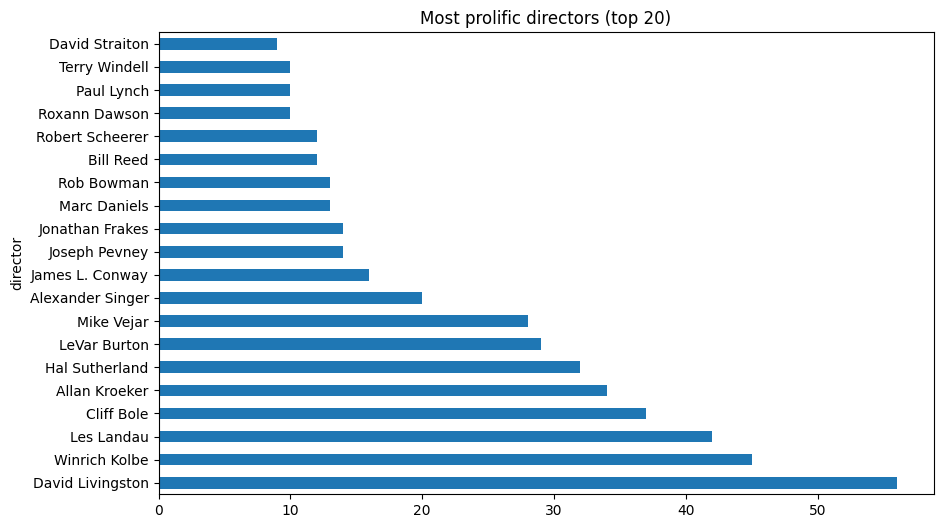

In [8]:
# Most prolific directors
episodes["director"].dropna().value_counts().head(20).plot.barh(
    figsize=(10, 6), title="Most prolific directors (top 20)"
)

Text(0.5, 0, 'Episodes')

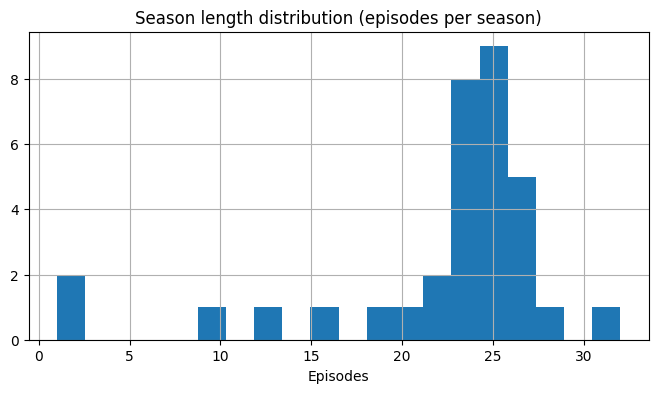

In [9]:
# Season length distribution
season_lengths = (
    episodes.dropna(subset=["show_title", "season"])
    .groupby(["show_title", "season"])
    .size()
    .reset_index(name="episode_count")
)
season_lengths["episode_count"].hist(bins=20, figsize=(8, 4))
plt.title("Season length distribution (episodes per season)")
plt.xlabel("Episodes")

In [10]:
(episodes.isna().mean() * 100).sort_values(ascending=False).rename("null %").to_frame()

,null %
stardate,100.000000
air_date,99.199085
production_code,21.510297
season,16.819222
director,16.018307
writer,14.874142
description,13.844394
episode_number,2.517162
show_title,1.144165
title,0.000000


## 4  Movies

In [11]:
display(
    movies[["title", "release_year", "director", "timeline", "box_office", "budget"]]
    .sort_values("release_year")
)

,title,release_year,director,timeline,box_office,budget


<Axes: title={'center': 'Timeline split'}>

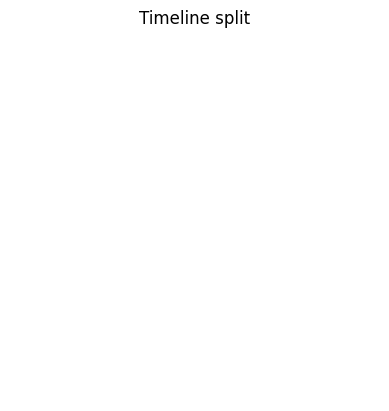

In [12]:
movies["timeline"].value_counts().plot.pie(autopct="%1.0f%%", title="Timeline split")

## 5  Books

In [13]:
if books.empty:
    print("No books extracted yet — re-run the star_trek extraction job to populate.")
else:
    books["media_type"].value_counts().plot.bar(title="Books by media type")

No books extracted yet — re-run the star_trek extraction job to populate.


In [14]:
if not books.empty:
    books["publication_year"].dropna().astype(int).hist(bins=30, figsize=(10, 4))
    plt.title("Star Trek book publication years")
    plt.xlabel("Year")

In [15]:
if not books.empty:
    books["series"].dropna().value_counts().head(20).plot.barh(
        figsize=(10, 6), title="Top book series (top 20)"
    )

## 6  Characters

<Axes: title={'center': 'Characters by species (top 20)'}, ylabel='species'>

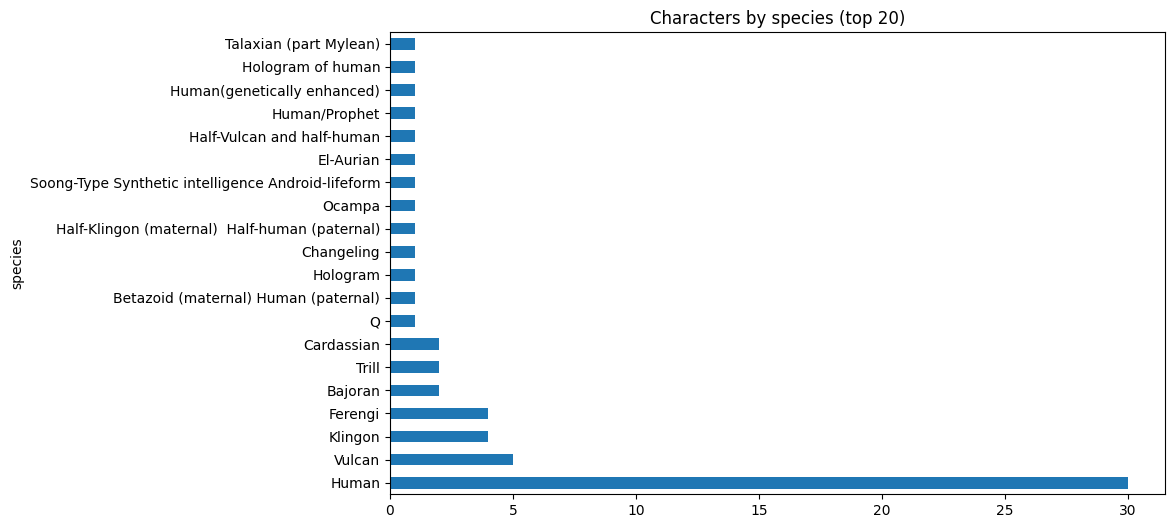

In [16]:
# Species distribution
characters["species"].dropna().value_counts().head(20).plot.barh(
    figsize=(10, 6), title="Characters by species (top 20)"
)

<Axes: title={'center': 'Characters by rank (top 20)'}, ylabel='rank'>

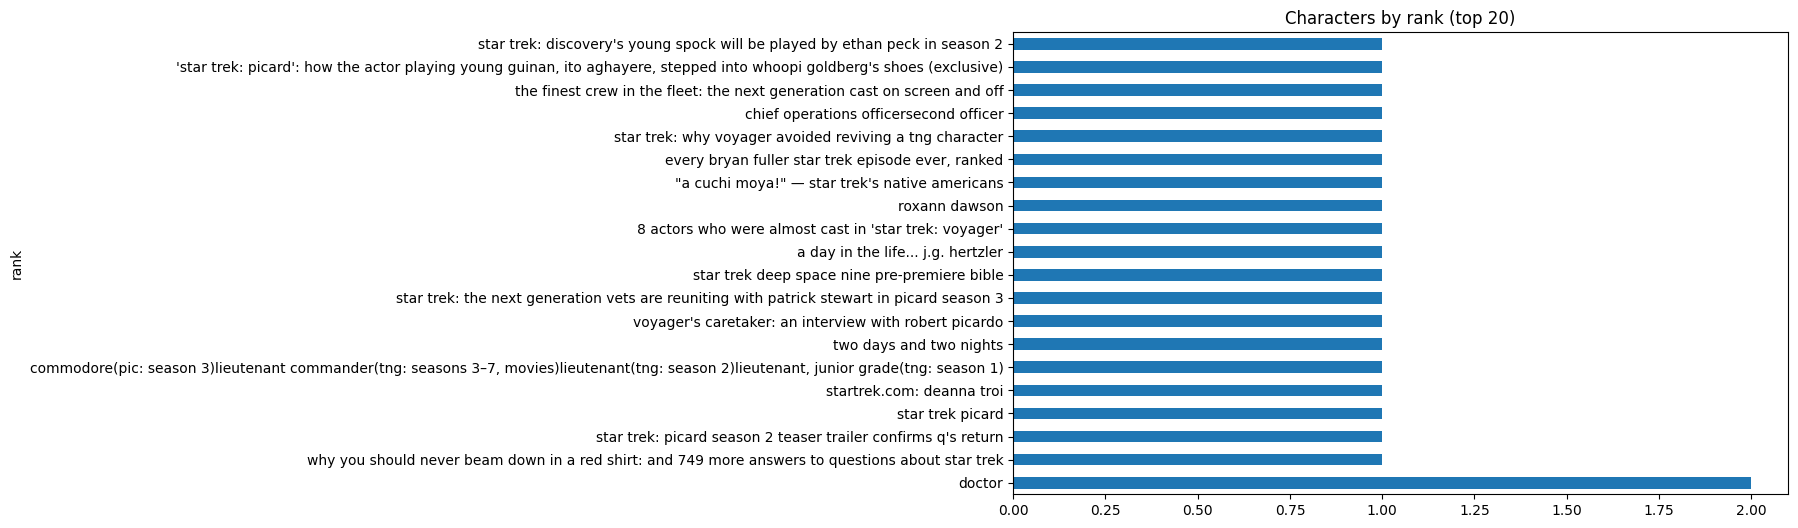

In [17]:
# Rank distribution
characters["rank"].dropna().str.lower().value_counts().head(20).plot.barh(
    figsize=(10, 6), title="Characters by rank (top 20)"
)

<Axes: title={'center': 'Top character affiliations (top 20)'}, ylabel='affiliation'>

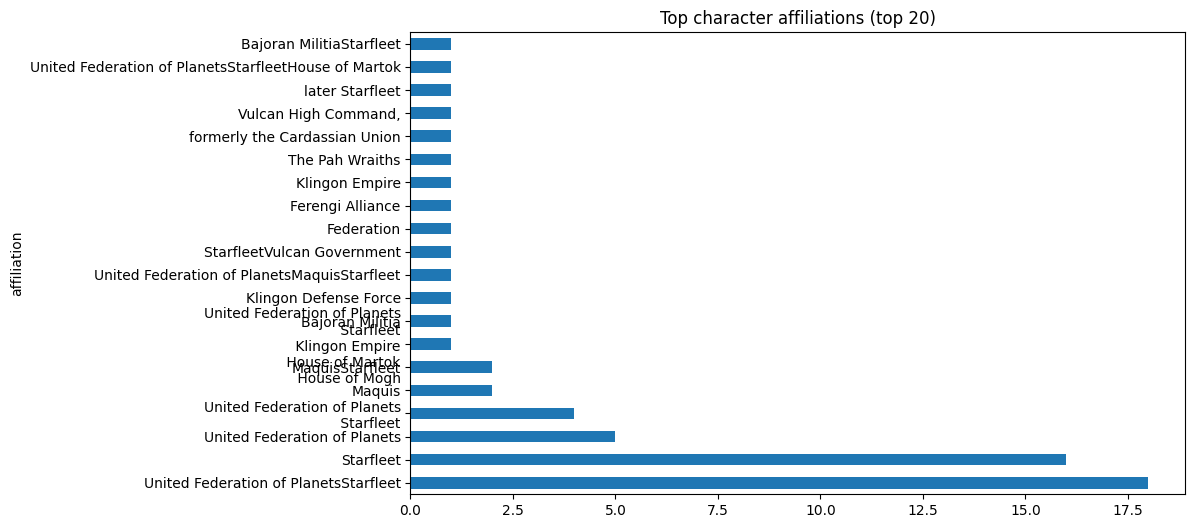

In [18]:
# Pipe-separated affiliation → explode into individual values
_LIST_TMPLS = frozenset({"hlist", "flatlist", "plainlist", "unbulleted list", "ubl"})


def _split_pipe(val: str) -> list[str]:
    return [x.strip() for x in str(val).split("|") if x.strip()]


(
    characters["affiliation"]
    .dropna()
    .apply(_split_pipe)
    .explode()
    .str.strip()
    .value_counts()
    .head(20)
    .plot.barh(figsize=(10, 6), title="Top character affiliations (top 20)")
)

## 7  Species

<Axes: title={'center': 'Species by quadrant'}>

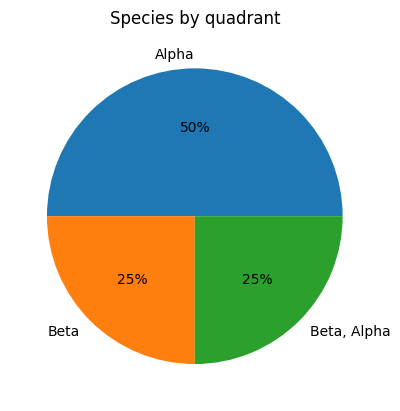

In [19]:
species["quadrant"].dropna().value_counts().plot.pie(autopct="%1.0f%%", title="Species by quadrant")

In [20]:
display(
    species[["title", "quadrant", "homeworld", "affiliation"]]
    .sort_values("title")
    .head(30)
)

,title,quadrant,homeworld,affiliation
37,Aaamazzarite,NaN,NaN,NaN
119,Acamarian,NaN,NaN,NaN
58,Aenar,NaN,NaN,NaN
71,Akritirian,NaN,NaN,NaN
83,Allasomorph,NaN,NaN,NaN
36,Amoeba (Star Trek),NaN,NaN,NaN
13,Andorian,"Beta, Alpha",Andoria,United Federation of Planets|Andorian Empire
27,Angosian,NaN,NaN,NaN
87,Ankari,NaN,NaN,NaN
30,Antedean,NaN,NaN,NaN


## 8  Cross-table analysis

<Axes: title={'center': 'Directors by number of shows'}, ylabel='director'>

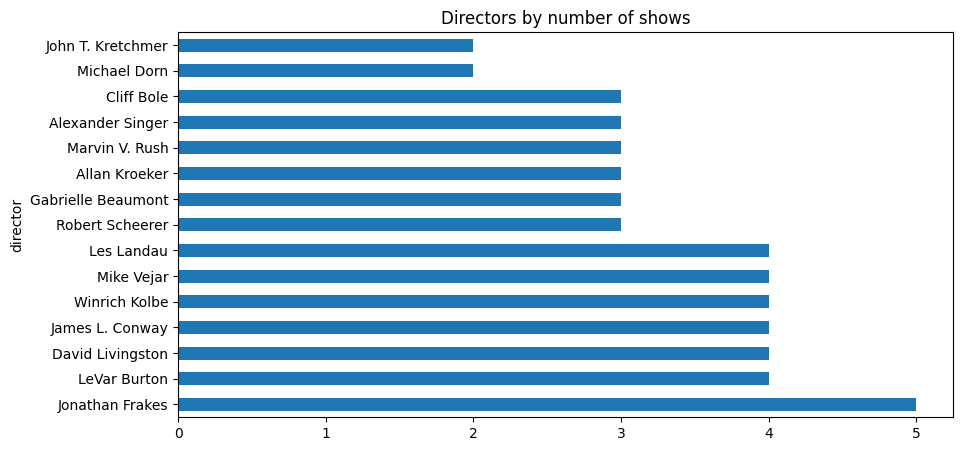

In [21]:
# Directors who worked across multiple shows
dir_shows = (
    episodes.dropna(subset=["director", "show_title"])
    .groupby("director")["show_title"]
    .nunique()
    .sort_values(ascending=False)
)
dir_shows.head(15).plot.barh(figsize=(10, 5), title="Directors by number of shows")

In [22]:
# Movie directors who also directed TV episodes
movie_dirs = set(movies["director"].dropna().str.split("|").explode().str.strip())
ep_dirs    = set(episodes["director"].dropna().str.strip())
both = sorted(movie_dirs & ep_dirs)
print(f"Directors who did both films and TV episodes ({len(both)}):")
for d in both:
    print(" ", d)

Directors who did both films and TV episodes (0):


## 9  Wikitext lookup from preprocessed dump

In [23]:
%pip install bz2
%pip install rich

/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.
/home/benwright/Documents/GitHub/wiki/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [24]:
import bz2
import struct

import numpy as np

from wiki_dumps.dumps.preprocess import load_raw_index, raw_paths

_dump_files = sorted(DUMP_DIR.glob("*-pages-articles-multistream.xml.bz2"))
assert _dump_files, f"No dump found in {DUMP_DIR}"
DUMP_PATH  = _dump_files[-1]
INDEX_PATH = Path(str(DUMP_PATH).replace(
    "-pages-articles-multistream.xml.bz2",
    "-pages-articles-multistream-index.txt.bz2",
))
RAW_PATH, IDX_PATH = raw_paths(DUMP_PATH)

print("Dump: ", DUMP_PATH.name)
print("Raw:  ", RAW_PATH.name, "exists:", RAW_PATH.exists())
print("Index:", IDX_PATH.name, "exists:", IDX_PATH.exists())

Dump:  enwiki-20260801-pages-articles-multistream.xml.bz2
Raw:   enwiki-20260801-pages-articles-multistream.xml.raw exists: True
Index: enwiki-20260801-pages-articles-multistream.xml.raw.idx exists: True


In [25]:
_raw_index = load_raw_index(IDX_PATH)

_pids: list[int] = []
_blks: list[int] = []
block_idx = -1
prev_offset = -1

with bz2.open(INDEX_PATH, "rt", encoding="utf-8") as f:
    for line in f:
        line = line.rstrip("\n")
        fc = line.index(":")
        sc = line.index(":", fc + 1)
        offset  = int(line[:fc])
        page_id = int(line[fc + 1 : sc])
        if offset != prev_offset:
            block_idx += 1
            prev_offset = offset
        _pids.append(page_id)
        _blks.append(block_idx)

_pid_arr = np.array(_pids, dtype=np.int64)
_blk_arr = np.array(_blks, dtype=np.int32)
_sort_order = np.argsort(_pid_arr, kind="stable")
_pid_arr = _pid_arr[_sort_order]
_blk_arr = _blk_arr[_sort_order]
del _pids, _blks, _sort_order

print(f"Index: {len(_pid_arr):,} pages, {_blk_arr.max()+1:,} blocks")
print(f"Memory: {(_pid_arr.nbytes + _blk_arr.nbytes) / 1e6:.1f} MB")

Index: 25,792,234 pages, 257,960 blocks
Memory: 309.5 MB


In [26]:
from wiki_dumps.parse.types import WikiPage


def fetch_page(page_id: int) -> WikiPage | None:
    """Return the WikiPage for *page_id* by seeking into the raw dump."""
    pos = int(np.searchsorted(_pid_arr, page_id))
    if pos >= len(_pid_arr) or _pid_arr[pos] != page_id:
        return None
    block_idx = int(_blk_arr[pos])
    offset, length = _raw_index[block_idx]
    with RAW_PATH.open("rb") as fh:
        fh.seek(offset)
        xml_bytes = fh.read(length)
    for page in iter_pages_from_xml_bytes(xml_bytes):
        if page.page_id == page_id:
            return page
    return None


def fetch_wikitext(page_id: int) -> str:
    page = fetch_page(page_id)
    return page.wikitext if page else ""


# Quick smoke test on first episode
if not episodes.empty:
    sample_pid = int(episodes["page_id"].iloc[0])
    page = fetch_page(sample_pid)
    if page:
        print(f"{page.title!r}  ({len(page.wikitext):,} chars)")
        print(page.wikitext[:600])

'List of Star Trek: Enterprise episodes'  (13,143 chars)
{{Short description|None}}
{{DISPLAYTITLE:List of ''Star Trek: Enterprise'' episodes}}
{{Use American English|date=March 2026}}
{{Use mdy dates|date=October 2011}}
[[File:Star Trek ENT logo.svg|right|300px]]
''[[Star Trek: Enterprise]]'' is an American [[Science fiction on television|science fiction television]] series that originally aired on the [[UPN]] network from September 26, 2001 to May 13, 2005.<ref name=tvguideeplist>{{cite magazine|title=Star Trek: Enterprise Episodes on UPN|url=http://www.tvguide.com/tvshows/star-trek-enterprise/episodes/100410|archive-url=https://web.archive.org/we


## 10  Prototype new extract fields
Grab a sample of pages, fetch their wikitext, and try parsing new fields.
Once happy with the logic, copy it into `star_trek.py`.

In [27]:
def _infobox_value(wikicode, key: str) -> str | None:
    for tmpl in wikicode.filter_templates():
        if tmpl.has(key):
            return str(tmpl.get(key).value).strip() or None
    return None


# ── prototype a new field here ────────────────────────────────────────────
def extract_new_episode_fields(page_id: int) -> dict:
    wikitext = fetch_wikitext(page_id)
    if not wikitext:
        return {"guests": None, "story": None}
    wikicode = mwparserfromhell.parse(wikitext)
    return {
        "guests": _infobox_value(wikicode, "guests"),
        "story":  _infobox_value(wikicode, "story"),
        # Add more keys here to prototype additional fields
    }


# Run on a small sample (one disk seek per page)
SAMPLE_N = 20
if not episodes.empty:
    sample = episodes.head(SAMPLE_N).copy()
    new_fields = pd.DataFrame(
        [extract_new_episode_fields(int(pid)) for pid in sample["page_id"]],
        index=sample.index,
    )
    display(pd.concat([sample[["title", "show_title", "season", "director"]], new_fields], axis=1))

,title,show_title,season,director,guests,story
0,List of Star Trek: Enterprise episodes,NaN,NaN,NaN,None,None
1,List of Star Trek: The Original Series episodes,NaN,NaN,12,None,None
2,Beyond the Farthest Star,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
3,Yesteryear,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
4,One of Our Planets Is Missing,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
5,The Lorelei Signal,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
6,"More Tribbles, More Troubles",Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
7,The Survivor,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
8,The Infinite Vulcan,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None
9,The Magicks of Megas-tu,Star Trek: The Animated Series,1.0,Hal Sutherland,None,None


## 12  Lazy Dask DataFrame with wikitext column
Backed by the episodes table; `wikitext` is a delayed disk lookup.

In [28]:
if not episodes.empty:
    ddf = dd.from_pandas(episodes, npartitions=8)
    ddf = ddf.assign(wikitext=ddf["page_id"].map(fetch_wikitext, meta=("wikitext", "str")))
    print(ddf)
    ddf.dtypes

Dask DataFrame Structure:
                  id page_id   title show_title   season episode_number production_code air_date stardate director  writer description wikitext
npartitions=8                                                                                                                                  
0              int64   int64  string     string  float64        float64          string   string   string   string  string      string      str
110              ...     ...     ...        ...      ...            ...             ...      ...      ...      ...     ...         ...      ...
...              ...     ...     ...        ...      ...            ...             ...      ...      ...      ...     ...         ...      ...
765              ...     ...     ...        ...      ...            ...             ...      ...      ...      ...     ...         ...      ...
873              ...     ...     ...        ...      ...            ...             ...      ...      ...     

In [29]:
# Materialize a small slice
if not episodes.empty:
    sample_lazy = ddf.head(5)
    sample_lazy[["title", "show_title"]].assign(
        wikitext_len=sample_lazy["wikitext"].str.len()
    )[["title", "show_title", "wikitext_len"]]

## 13  Inspect a single page interactively

In [30]:
# Change TITLE to any episode/movie/character title in the DB
if not episodes.empty:
    TITLE = episodes["title"].iloc[0]
    row  = episodes[episodes["title"] == TITLE].iloc[0]
    page = fetch_page(int(row["page_id"]))

    if page:
        wikicode = mwparserfromhell.parse(page.wikitext)
        print(f"== {page.title} ==")
        print(f"categories: {page.categories[:6]} ...")
        print()
        for tmpl in wikicode.filter_templates():
            tmpl_name = str(tmpl.name).strip()
            if any(kw in tmpl_name.lower() for kw in ("infobox", "star trek")):
                print(f"Template: {tmpl_name}")
                for param in tmpl.params:
                    val = str(param.value).strip()
                    if val:
                        print(f"  {str(param.name).strip()!s:30s} = {val[:80]}")
                print()

== List of Star Trek: Enterprise episodes ==
categories: ('Star Trek: Enterprise episodes', 'Star Trek episode lists', 'Lists of American science fiction television series episodes') ...

Template: DISPLAYTITLE:List of ''Star Trek: Enterprise'' episodes

Template: :Star Trek: Enterprise season 1

Template: :Star Trek: Enterprise season 2

Template: :Star Trek: Enterprise season 3

Template: :Star Trek: Enterprise season 4

Template: Star Trek: Enterprise episodes

Template: Star Trek: Enterprise

Template: Star Trek



In [31]:
episodes.head(100)

,id,page_id,title,show_title,season,episode_number,production_code,air_date,stardate,director,writer,description
0,1,27075,List of Star Trek: Enterprise episodes,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,right|300px\nStar Trek: Enterprise is an Ameri...
1,2,27090,List of Star Trek: The Original Series episodes,NaN,NaN,NaN,NaN,12,NaN,12,31,"right|228x228px\nCreated by Gene Roddenberry, ..."
2,3,27092,Beyond the Farthest Star,Star Trek: The Animated Series,1.0,1.0,NaN,NaN,NaN,Hal Sutherland,Samuel A. Peeples,While exploring on the outermost rim of the ga...
3,4,27092,Yesteryear,Star Trek: The Animated Series,1.0,2.0,NaN,NaN,NaN,Hal Sutherland,D. C. Fontana,Spock must travel to the past to rescue his yo...
4,5,27092,One of Our Planets Is Missing,Star Trek: The Animated Series,1.0,3.0,NaN,NaN,NaN,Hal Sutherland,Marc Daniels,The Enterprise encounters a giant cloud creatu...
...,...,...,...,...,...,...,...,...,...,...,...,...
95,96,600462,Sins of the Father (Star Trek: The Next Genera...,Star Trek: The Next Generation,3.0,17.0,165,NaN,NaN,Les Landau,Ronald D. Moore|W. Reed Moran|Drew Deighan,"""Sins of the Father"" is the 65th episode of th..."
96,97,602537,The Search (Star Trek: Deep Space Nine),Star Trek: Deep Space Nine,3.0,1.0,447 and 448,NaN,NaN,Kim Friedman (Part I)\n Jonathan Frakes (Part II),Ronald D. Moore (Part I)|Ira Steven Behr (Part...,"""The Search"" is the 47th and 48th episode of t..."
97,98,606014,"Elementary, Dear Data",Star Trek: The Next Generation,2.0,3.0,129,NaN,NaN,Rob Bowman,Brian Alan Lane,"""Elementary, Dear Data"" is the third episode o..."
98,99,606019,Ship in a Bottle (Star Trek: The Next Generation),Star Trek: The Next Generation,6.0,12.0,238,NaN,NaN,Alexander Singer,René Echevarria,"""Ship in a Bottle"" is the 138th episode of the..."
